# **Problema de ir ou não ir ao jogo**

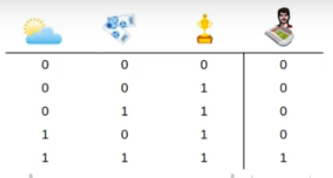

Neste vídeo vamos aprender como construir uma rede neural simples usando Python e as biblioteca Keras e NumPy para resolver o problema de "ir ou não ir ao jogo". Vamos explicar cada linha do código para que você entenda não só o que cada comando faz, mas também o porquê de cada escolha. Vamos lá!"

# **Incluindo as Bibliotecas**

Inicialmente, vamos carregar as bibliotecas.

In [13]:
import numpy as np
from keras import models, layers

Utilizamos o numpy, que é uma biblioteca útil para lidar com números e matrizes, e o Keras, que é uma biblioteca que facilita a criação de redes neurais. Importar os módulos "layers" e "models" do keras.

# **Dados de Treinamento e Teste**


Vamos definir agora os valores dos dados de treinamento e de teste.

Neste exemplo, os dados de treinamento possuem 3 valores por linha, que representam as condições climáticas, o preço do ingresso e a importância do jogo.
Os rótulos desses dados possui um único valor por linha, que representa a decisão de ir ou não ir ao jogo (1 ou 0).

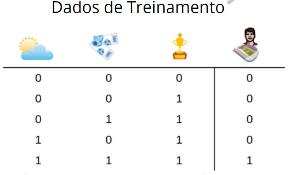  

Os dados de teste possuem os mesmo formato, possuem também 3 valores por linha. Os rótulos dos dados de teste possuem um único valor, que representa a minha decisão de ir ou náo ir ao jogo

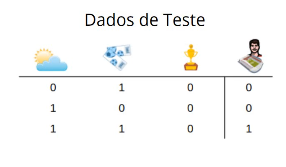



In [14]:
x_train = np.array([
    [0, 0, 0],
    [0, 0, 1],
    [0, 1, 1],
    [1, 0, 1],
    [1, 1, 1]
], dtype=np.float32)
y_train = np.array([0, 0, 0, 0, 1], dtype=np.float32)

x_test = np.array([
    [0, 1, 0],
    [1, 0, 0],
    [1, 1, 0]
], dtype=np.float32)
y_test = np.array([0, 0, 1], dtype=np.float32)

 Para representar os dados de treino e teste, criamos um array usando o a numpy onde cada linha representa uma combinação possível de três condições (situação climática, o preço do ingresso e a importância do jogo).

Os rótulos desses dados também são armazenados em arrays do numpy

Com esses dados de treino e teste podemos ensinar a rede neural.

Definimos também o tipo dos valores como float32, porque as redes neurais trabalham melhor com números reais do que inteiros

#**Construindo o Modelo**

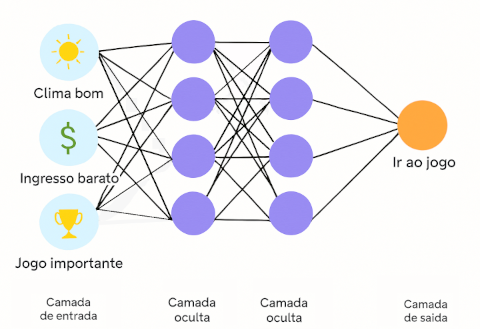

Para construir o modelo, vamos utilizar o módulo do Keras Models, que contém classes e funções para definir arquiteturas de modelos de redes neurais.

In [15]:
model = models.Sequential()

Utilizamos a classe Sequential, em que as camadas são empilhadas

#**Incluindo a Camadas de Entrada**

Vamos agora incluir uma camada ao nosso modelo. Para isso utilizamos o método add.

In [16]:
model.add(layers.Input(shape=(3,), name='input_layer'))

Do módulo layer, utilizamos a classe Input para incluir uma camada que é a porta de entrada dos nossos dados.

O Input diz ao modelo que, para cada exemplo, teremos 3 números (Clima, importancia e Preço), inicializando os pesos das features.

Utilizamos o parametro 'name' para definir o nome da camada.


#**Incluindo as Camadas Ocultas**

Vamos agora incluir as Camadas Ocultas, utilizando do módulo 'layer' camada 'Dense'.

In [17]:
model.add(layers.Dense(4, activation='tanh', name='hidden_layer_1'))
model.add(layers.Dense(4, activation='tanh', name='hidden_layer_2'))

Criamos uma “camada densa” ou “camada totalmente conectada”, onde cada neurônio faz cálculos olhando para todas as entradas.

Essa camada terá 4 neurônios. Usamos 4 neurônios porque pode ser suficiente para o modelo aprender padrões.

Utilizamos neste exemplo a função tangente hiperbólica, que transforma a soma de cada neurônio em um número entre -1 e 1. Essa função é adequada para problemas desse tipo

Utilizamos também o parametro 'name' para dar um nome à camada.

Incluímos também uma nova camada oculta, com os mesmos parametros da anterior, embora, uma única camada possa funcionar bem para esse problema simples

#**Camada de Saída**

Definidas as camadas ocultas, vamos criar agora a camada de saída. Essa camada terá um neurônio só — porque queremos prever só um valor final (0 ou 1 - "irei" ou "não irei ao jogo").

In [18]:
model.add(layers.Dense(1, activation='sigmoid', name='output_layer'))

Nesta camada, utilizamos a função de ativação 'sigmoid', que transforma qualquer número em uma saída entre 0 e 1.

Se o valor previsto passar de meio (0.5), consideramos que o resultado será 1. Caso contrário, será zero. Utilizamos o parametro 'name' dar um nome à camada.

#**Compilando o Modelo**

O passo seguinte é a compilação do modelo. Compilar um modelo é como configurar as regras do treinamento — definimos como ele aprende, que tipo de erro corrigir e como medir o progresso.

In [19]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

O primeiro parâmetro define o otimizador. O otimizador é que calcula como ajustar cada peso da rede para tentar errar menos. O `adam` é um otimizador adequado para um problema desse tipo.

Para classificações que só podem ser 0 ou 1, a `binary_crossentropy` é a escolha mais indicada para a função de perda.

Utilizamos a métrica acurácia para acompanhar o treinamento.

#**Resumo do Modelo**

O método summary() mostra quantas camadas nossa rede possui, quantos neurônios têm em cada uma, e quantos são os parâmetros treináveis.

In [20]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 4)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

#**Treinando a Rede**

Vamos agora chamar o método fit, que é o responsável pelo aprendizado da rede.

Aqui, o modelo vai olhar para seus dados de entrada (X) e saída (y) várias vezes e ajustar seus parâmetros internos, aprendendo quais pesos e conexões produzem as respostas certas.

In [21]:
model.fit(x_train, y_train, epochs=300, verbose=2)

Epoch 1/300
1/1 - 1s - 651ms/step - accuracy: 0.6000 - loss: 0.6990
Epoch 2/300
1/1 - 0s - 26ms/step - accuracy: 0.6000 - loss: 0.6961
Epoch 3/300
1/1 - 0s - 24ms/step - accuracy: 0.6000 - loss: 0.6933
Epoch 4/300
1/1 - 0s - 25ms/step - accuracy: 0.6000 - loss: 0.6904
Epoch 5/300
1/1 - 0s - 24ms/step - accuracy: 0.6000 - loss: 0.6876
Epoch 6/300
1/1 - 0s - 27ms/step - accuracy: 0.6000 - loss: 0.6848
Epoch 7/300
1/1 - 0s - 25ms/step - accuracy: 0.6000 - loss: 0.6820
Epoch 8/300
1/1 - 0s - 25ms/step - accuracy: 0.6000 - loss: 0.6791
Epoch 9/300
1/1 - 0s - 25ms/step - accuracy: 0.6000 - loss: 0.6763
Epoch 10/300
1/1 - 0s - 24ms/step - accuracy: 0.6000 - loss: 0.6736
Epoch 11/300
1/1 - 0s - 23ms/step - accuracy: 0.6000 - loss: 0.6708
Epoch 12/300
1/1 - 0s - 29ms/step - accuracy: 0.6000 - loss: 0.6680
Epoch 13/300
1/1 - 0s - 21ms/step - accuracy: 0.6000 - loss: 0.6652
Epoch 14/300
1/1 - 0s - 28ms/step - accuracy: 0.6000 - loss: 0.6625
Epoch 15/300
1/1 - 0s - 17ms/step - accuracy: 0.6000 - l

Enviamos ao método Fit os dados de entrada X e os rótulos

Definimos que a rede deve passar pelos dados 300 vezes, ou seja, o parametro época receberá o valor 300.

Configuramos o parâmetro opcional "verbose=2" para que os resultados intermediários do treinamento fossem exibidos de forma mais resumida.

#**Observação**

Em Problemas Pequenos e Didáticos, é comum alcançar acurácia 1 (100%). Em Problemas Reais, alcancar 100% de acurácia no treinamento não é comum.

#**Verificando se o aprendizado ocorreu**

Vamos agora utilizar o método "Evaluate" para verificar o quanto a rede aprendeu.

Os dados de teste que enviamos ao modelo treinado não foram vistos pelo modelo durante o treinamento. Usar novos dados para teste é importante para que o modelo realmente aprendenda regras que poderão ser aplicadas em situações desconhecidas.

In [22]:
loss, accuracy = model.evaluate(x_test, y_test)
print(f'Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.3333 - loss: 0.8319
Test Loss: 0.8319, Test Accuracy: 0.3333


Passamos como parâmetro ao método 'evaluate' todos os exemplos do conjunto de teste (X_test) e seus respectivos rótulo. O método pega os exemplos do conjunto de teste, faz as previsões para cada entrada, compara essas previsões com os rótulos corretos (y_test) e retorna duas coisas:
* o 'loss' (que é o valor do erro): Esse valor representa o quanto, em média, a previsão foi diferente do esperado.
* e a accuracy (acurácia): que é a porcentagem das respostas que a rede acertou. Essa porcentagem é convertida para 0 ou 1, que são as classes possíveis, e, em seguida, esse resultado é comparado com o valor esperado, ou seja, o rótulo correpondente.

A saida do método evaluate é um panorama geral de como o modelo está se saindo no conjunto de teste.

O valor do erro e a acurácia, calculados pelo evaluate foram impressos na tela utilizando o comando print

#**Fazendo Previsões Individuais**

A saida do método evaluate é um panorama geral de como o modelo está se saindo no conjunto de teste.

Para obtermos individualmente as previsões do modelo para cada entrada específica, devemos utilizar o método 'predict'

O método predict passa cada linha de 'X_test' pela rede e retorna a probabilidade prevista para cada uma delas. Ou seja, retorna valores entre 0 e 1.

In [23]:
predictions = model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


O retorno de "predictions" é um array com as saídas que a rede calculou para cada entrada de 'X_test'. Cada valor estará entre 0 e 1 porque utilizamos a função de ativação sigmoid na camada de saída. Essa função retorna valores neste intervalo.

Se a nossa rede aprendeu bem, serão gerados valores próximos de 0 para casos em que o rótulo for zero ("Não vou ao jogo"), e valores próximos de 1 para casos em que o rótulo for 1 ("Vou ao jogo").

#**Exibindo os Resutlados**

Vamos agora criar um laço para mostrar os resultados de foma amigável

In [24]:
for i in range(len(x_test)):
    print(f'Input: {x_test[i]}, Predicted: {1 if predictions[i][0] >= 0.5 else 0}, Actual Label: {y_test[i]}')

Input: [0. 1. 0.], Predicted: 1, Actual Label: 0.0
Input: [1. 0. 0.], Predicted: 1, Actual Label: 0.0
Input: [1. 1. 0.], Predicted: 1, Actual Label: 1.0


Este laço passa por todos os exemplos da base de dados.
*  Pega o exemplo de teste atual (X_test[i]) e divide os três valores em variáveis separadas, clima, ing_barato, jogo_imp.
*  Pega a probabilidade prevista pelo modelo para esse exemplo, que está salva no array predictions.
    * Usa-se [i][0] porque predictions é uma matriz (array 2D), mesmo que tenha uma só coluna.
    * O valor armazenado em pred_proba está entre 0 e 1 (que é a saída da sigmoid) e representa o quanto o modelo acha provável que a pessoa vá ao jogo naquela combinação de condições.
*  A previsão de pertencer à classe 0 ou à classe 1 é armazenada na variável 'pred_class'
    *  Se a probabilidade prevista for maior que 0.5, 'pred_class' receberá 1.  
    *  Se a probabilidade prevista for igual ou menor que 0.5, 'pred_class' receberá 0.